<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Fall_2026/blob/main/Module%203/Homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Homework 5** for the Fall 2025 Course "Machine Learning for Materials Science", University of Tennessee Knoxville, Department of Materials Science and Engineering. Instructor Sergei V. Kalinin



# Graphene data set

We start with the same graphene data set that we explored in class. Run the full analysis in the notebook below.

## Import

In [ ]:
# Download the dataset, Will explain what each file corresponds to later
!gdown https://drive.google.com/uc?id=1-JZSRjIjNjkR0ZQ8ffRDAZ2FID53Yhon
!gdown https://drive.google.com/uc?id=1-84vLdGFsimD1jaTcGcMzNRCSvjId7-Y
!gdown https://drive.google.com/uc?id=1-Lowglj7fwEFaJoC9EBKDyfCIsMgOnyu

Downloading...
From (original): https://drive.google.com/uc?id=1-JZSRjIjNjkR0ZQ8ffRDAZ2FID53Yhon
From (redirected): https://drive.google.com/uc?id=1-JZSRjIjNjkR0ZQ8ffRDAZ2FID53Yhon&confirm=t&uuid=bbf37f9b-35eb-4340-ac3b-c65461f28955
To: /content/3DStack13-1-dec.npy
100% 157M/157M [00:09<00:00, 16.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-84vLdGFsimD1jaTcGcMzNRCSvjId7-Y
To: /content/3DStack13-1-exp.npy
100% 52.4M/52.4M [00:01<00:00, 50.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-Lowglj7fwEFaJoC9EBKDyfCIsMgOnyu
To: /content/3DStack13-1-coord.npy
100% 2.45M/2.45M [00:00<00:00, 141MB/s]


In [ ]:
# Installing AtomAI
# It will be used to split the image into local patches centered on atoms

!pip install atomai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 kB 14.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 66.6 MB/s eta 0:00:00
  Created wheel for mendeleev: filename=mendeleev-0.6.1-py2.py3-none-any.whl size=175054 sha256=d4d2e8cd4f268efd05f969ab606f6ed1458733846ff7f94dcf0710a0a627e315
  Stored in directory: /root/.cache/pip/wheels/79/b3/93/fce7f281f5581aae3887f1d60c9c091a96e784e2ce0833500c
Successfully built mendeleev


In [ ]:
# Importing necessary packages
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# We will use atomai just to create the dataset (sub-images)
import atomai as aoi
import cv2
import torch
import torch.nn as nn

import seaborn as sns
from scipy import stats

tt = torch.tensor

In [ ]:
STEM_real = np.load('3DStack13-1-exp.npy')   # raw STEM Image
decoded_imgs = np.load('3DStack13-1-dec.npy')   # oytput of DCNN where the each pixel is classified as one of the three classes (C, Si, or background)
lattice_coord = np.load('3DStack13-1-coord.npy', allow_pickle=True)[()]  # The atomic coodinates found by DCNN

## Visualization

For the ease of analysis, let's make the movie shorter

Text(0.5, 1.0, 'Atomic coordinates')

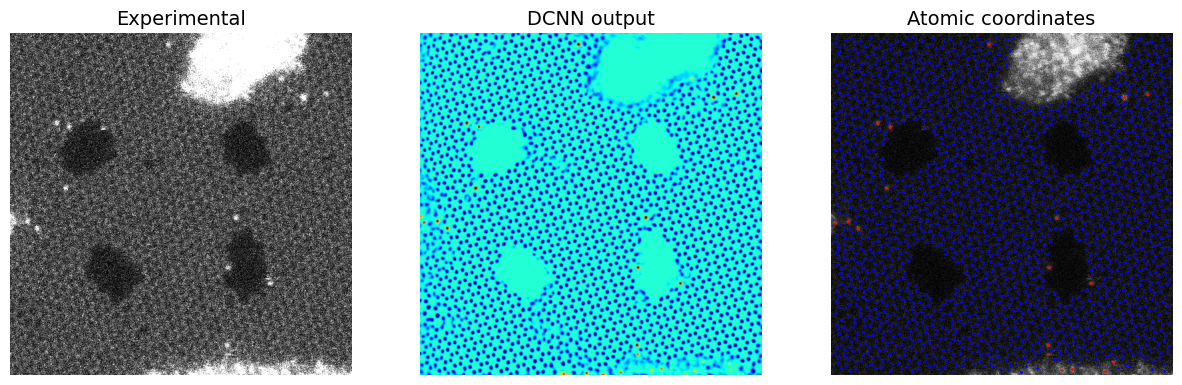

In [ ]:
#Vizualizing one frame of the data, we have 50 frames (0-49)

i = 3 # Choose movie frame

# Squeeze the channels in the predicted image (this is optional)
d_img = np.uint8(decoded_imgs[i]*255)
d_img = cv2.cvtColor(d_img, cv2.COLOR_BGR2GRAY)

# Get coordinates for C and Si atoms
lattice_coord_ = lattice_coord[i]
coord_Si = lattice_coord[i][np.where(lattice_coord[i][:,2]==1)][:,0:2]
coord_C = lattice_coord[i][np.where(lattice_coord[i][:,2]==0)][:,0:2]

# Plotting
fig = plt.figure(figsize = (15, 10), dpi = 100)
ax1 = fig.add_subplot(131)
ax1.imshow(STEM_real[i,:,:,0], vmin=0, vmax=0.3, cmap='gray')
ax1.axis('off')
ax1.set_title('Experimental', fontsize=14)
ax2 = fig.add_subplot(132)
ax2.imshow(d_img, cmap='jet', interpolation='Gaussian')
ax2.axis('off')
ax2.set_title('DCNN output', fontsize = 14)
ax3 = fig.add_subplot(133)
ax3.scatter(coord_Si[:,1], coord_Si[:,0], c='red', s=1)
ax3.scatter(coord_C[:,1], coord_C[:,0], c='blue', s=1)
ax3.imshow(STEM_real[i,:,:,0], cmap = 'gray')
ax3.axis('off')
ax3.set_title('Atomic coordinates', fontsize = 14)

## Creating features

In [ ]:
# Getting feature vectors
# Feature vectors here are the cropped images around the coordinates found by DCNN. The window_size of these cropped images can be changed below

window_size = 40   # Window_size

s = aoi.stat.imlocal(
    np.sum(decoded_imgs[..., :-1], -1)[..., None], # convert to a single channel (no background)
    lattice_coord, # Coodinates array, acts as the mid-point of the cropped sub-images
    window_size, 0)

In [ ]:
imstack = tt(s.imgstack[:,None,:,:, 0])
frames_all = s.imgstack_frames # will need for plotting VAE results
com_all = s.imgstack_com # will need for plotting VAE results

This code has created three objects. imstack is a collectrion of image patches of the size window_size. The object frames_all contain the information on the frame of the movie from which the image patch has come from. The object com_all contains the information on the coordinates of the patch (i.e. position of the atom that is its center) in the frame.

In [ ]:
imstack.shape, frames_all.shape, com_all.shape

(torch.Size([73995, 1, 40, 40]), (73995,), (73995, 2))

In [ ]:
np.unique(frames_all)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

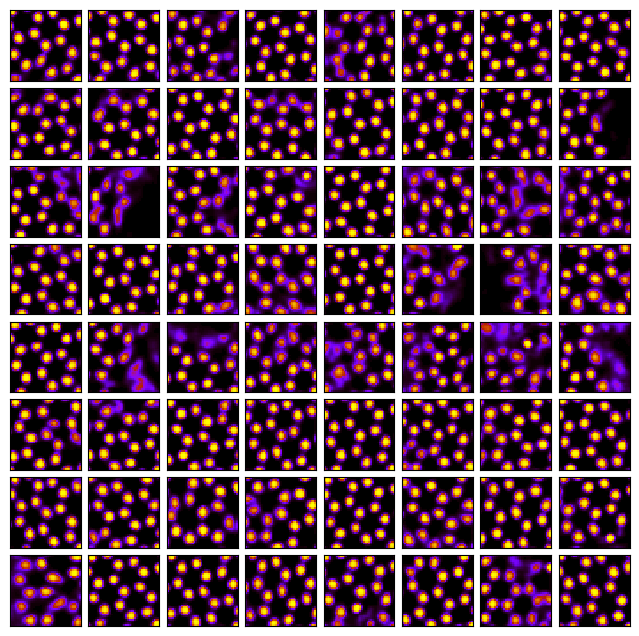

In [ ]:
# Vizualizing the training dataset

np.random.seed(1)  # fix seed so that we get the same samples displayed at every run
fig, axes = plt.subplots(8, 8, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for ax in axes.flat:
    i = np.random.randint(len(imstack))
    ax.imshow(imstack[i, 0], cmap='gnuplot', interpolation='nearest')

# plt.savefig('example_imgs.png', dpi = 300)

We can check the sizes of all objects we have created

In [ ]:
imstack.shape

torch.Size([73995, 1, 40, 40])

Now, we can select the patches and coordinates corresponding only to the first frame.

In [ ]:
imstack1 = imstack[frames_all == 1]
com_all1 = com_all[frames_all == 1]
imstack1.shape, com_all1.shape

(torch.Size([1798, 1, 40, 40]), (1798, 2))

## k-means clustering

And run the k-means clustering

In [ ]:
from sklearn.cluster import KMeans

a, b, c, d = imstack1.shape
imstack2 = imstack1.reshape(a, c * d)

nc = 3
km = KMeans(n_clusters=nc, random_state=0)
y_km = km.fit_predict(imstack2)

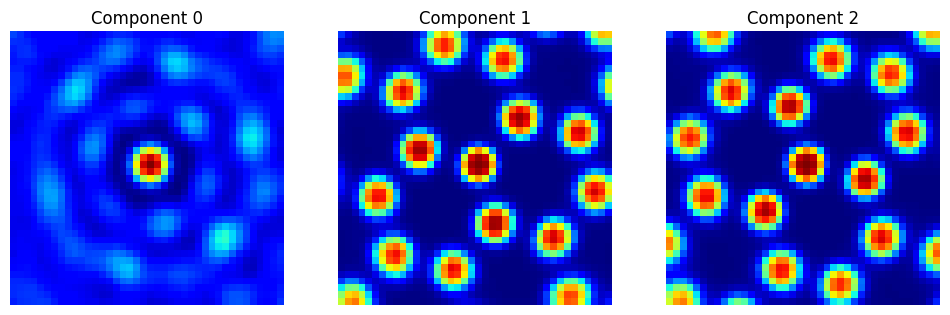

In [ ]:
rows = int(np.ceil(float(nc)/5))
cols = int(np.ceil(float(nc)/rows))

gs2 = gridspec.GridSpec(rows, cols)

fig2 = plt.figure(figsize = (4*cols, 4*(1+rows//1.5)))

for i in range(nc):
    ax2 = fig2.add_subplot(gs2[i])
    ax2.imshow(km.cluster_centers_[i,:].reshape(c, d), cmap = 'jet', origin = 'lower')
    ax2.set_title('Component ' + str(i))
    plt.tick_params(labelsize = 18)
    plt.axis('off')
plt.show()

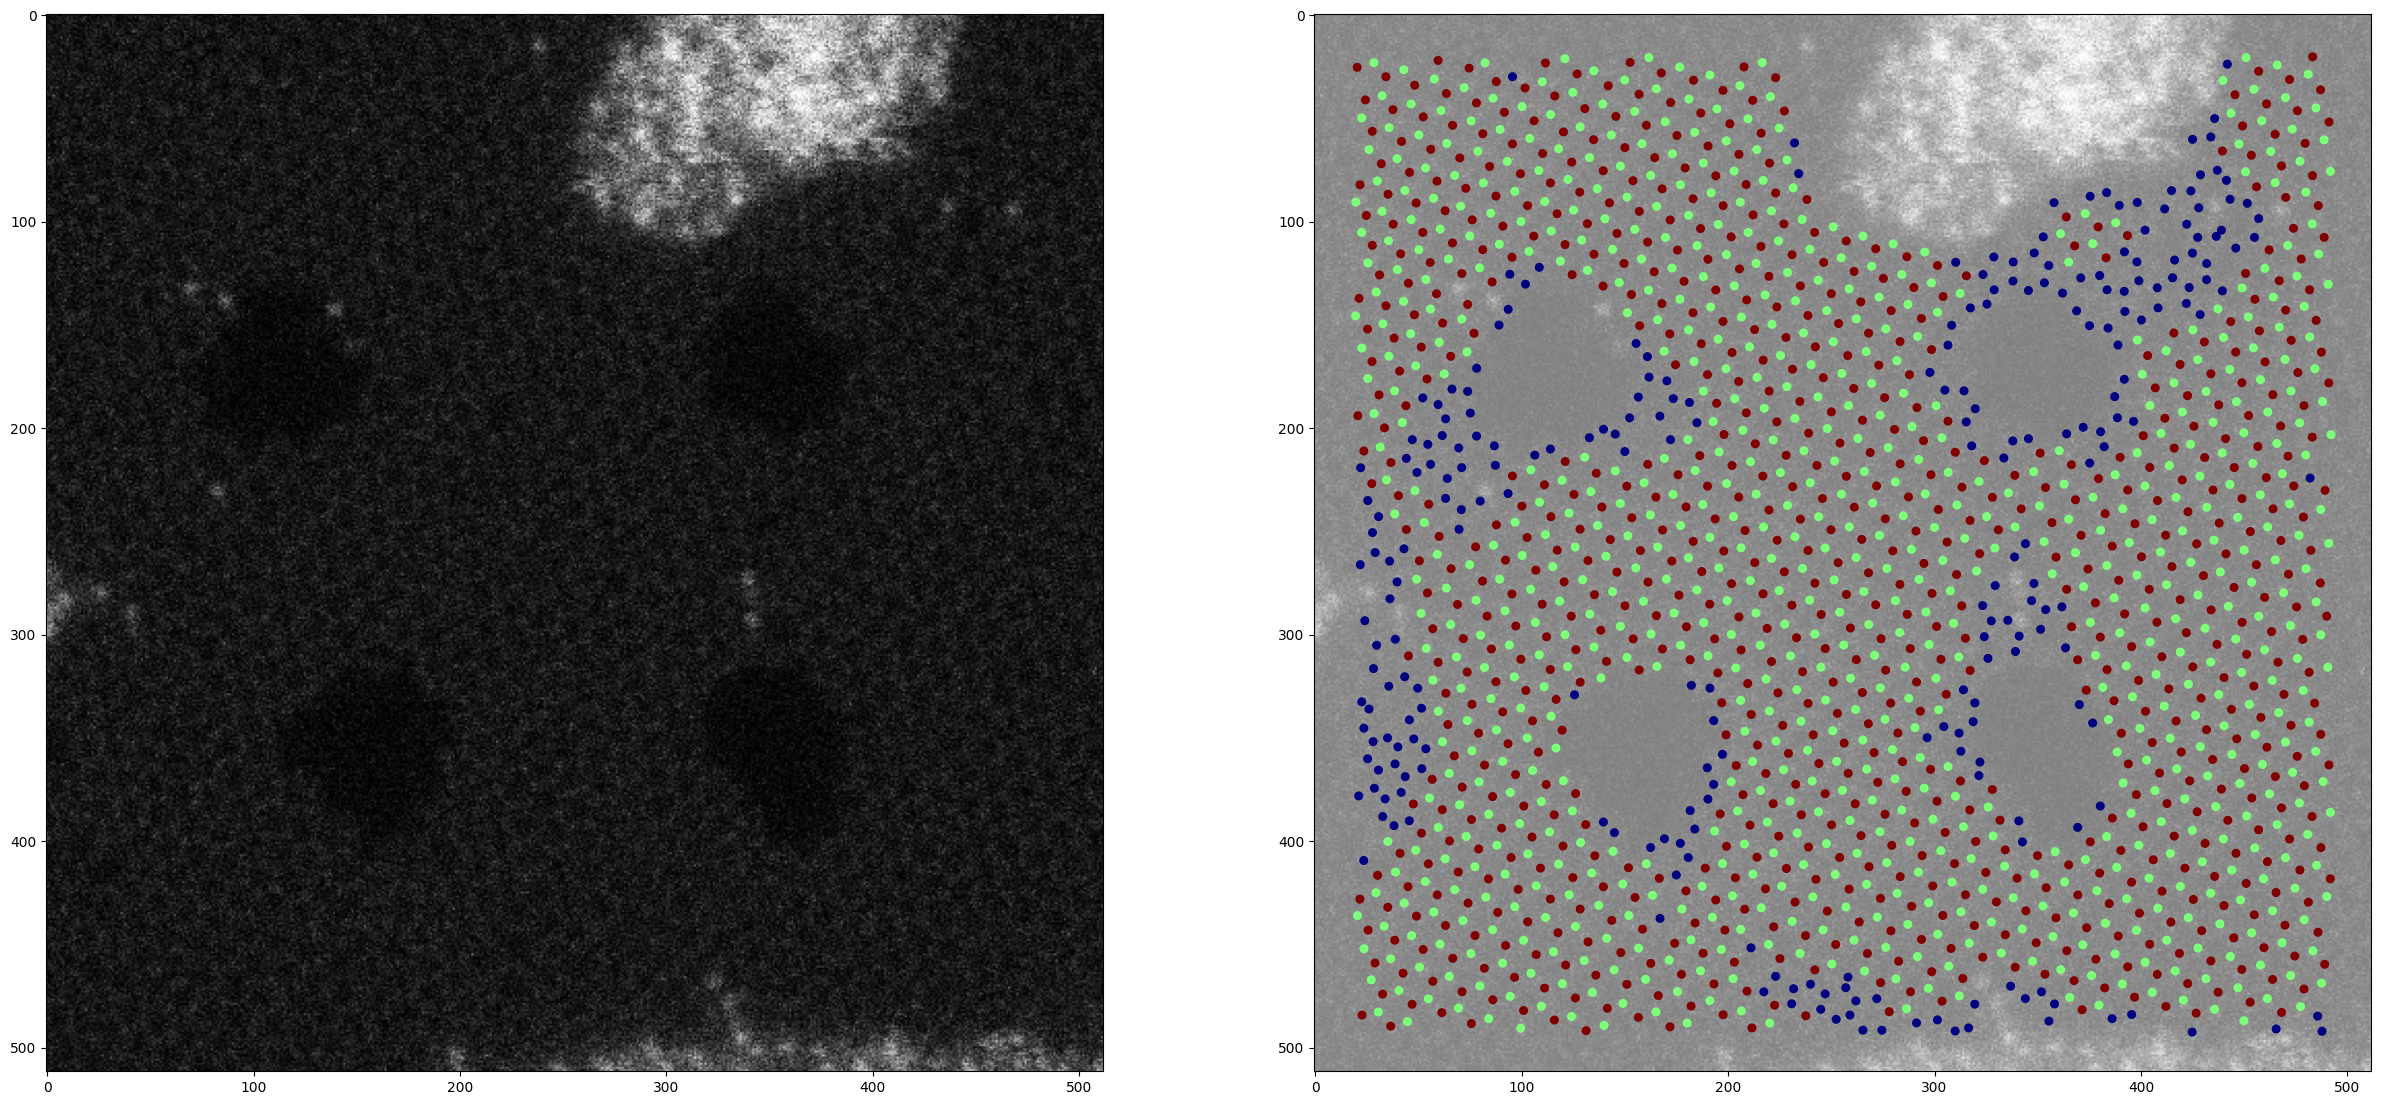

In [ ]:
#Visualizing the cluster labels on the raw STEM image

fig, ax = plt.subplots(1, 2, figsize=(30, 15))

ax[0].imshow(STEM_real[i,...,0], cmap="gray")
ax[1].imshow(STEM_real[i,...,0], cmap="gray", alpha = 0.5)
ax[1].scatter(com_all1[:, 1], com_all1[:, 0], c=y_km, s=30, cmap="jet")

plt.show()

## GMM clustering

In [ ]:
from sklearn.mixture import GaussianMixture as GMM

a, b, c, d = imstack1.shape
imstack2 = imstack1.reshape(a, c * d)

nc = 8
gmm = GMM(n_components=nc).fit(imstack2)
gr_labels = gmm.predict(imstack2)
gr_centers = gmm.means_

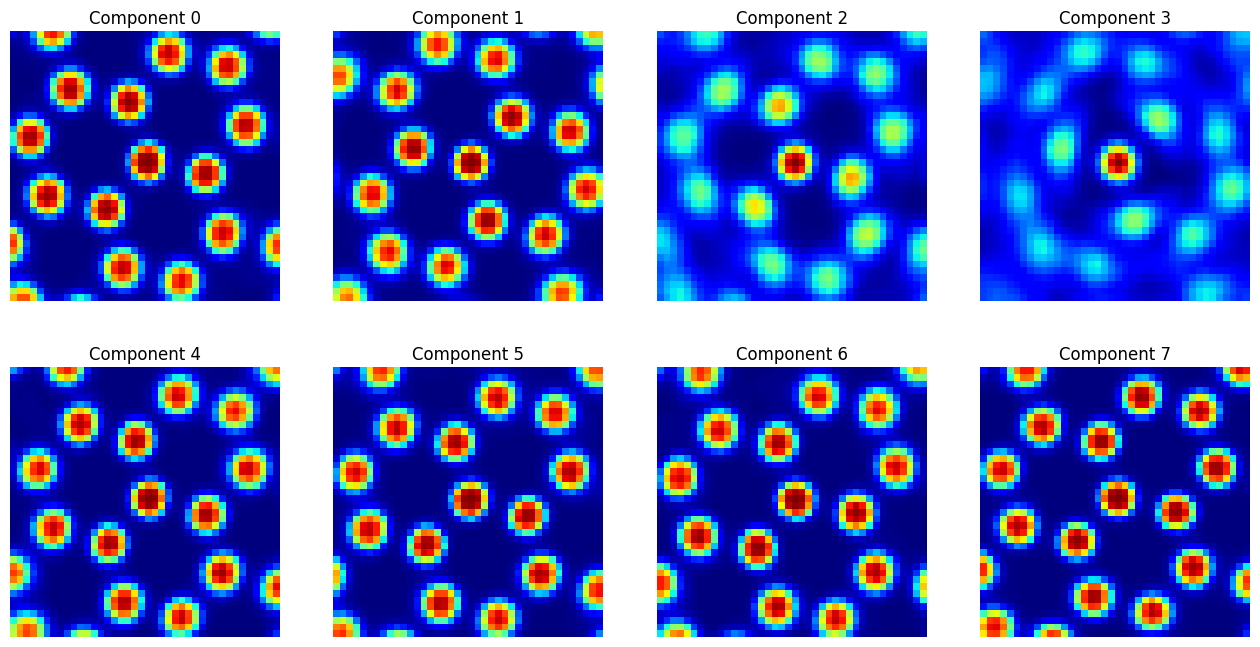

In [ ]:
rows = int(np.ceil(float(nc)/5))
cols = int(np.ceil(float(nc)/rows))

gs2 = gridspec.GridSpec(rows, cols)

fig2 = plt.figure(figsize = (4*cols, 4*(1+rows//1.5)))

for i in range(nc):
    ax2 = fig2.add_subplot(gs2[i])
    ax2.imshow(gr_centers[i,:].reshape(c, d), cmap = 'jet', origin = 'lower')
    ax2.set_title('Component ' + str(i))
    plt.tick_params(labelsize = 18)
    plt.axis('off')
plt.show()

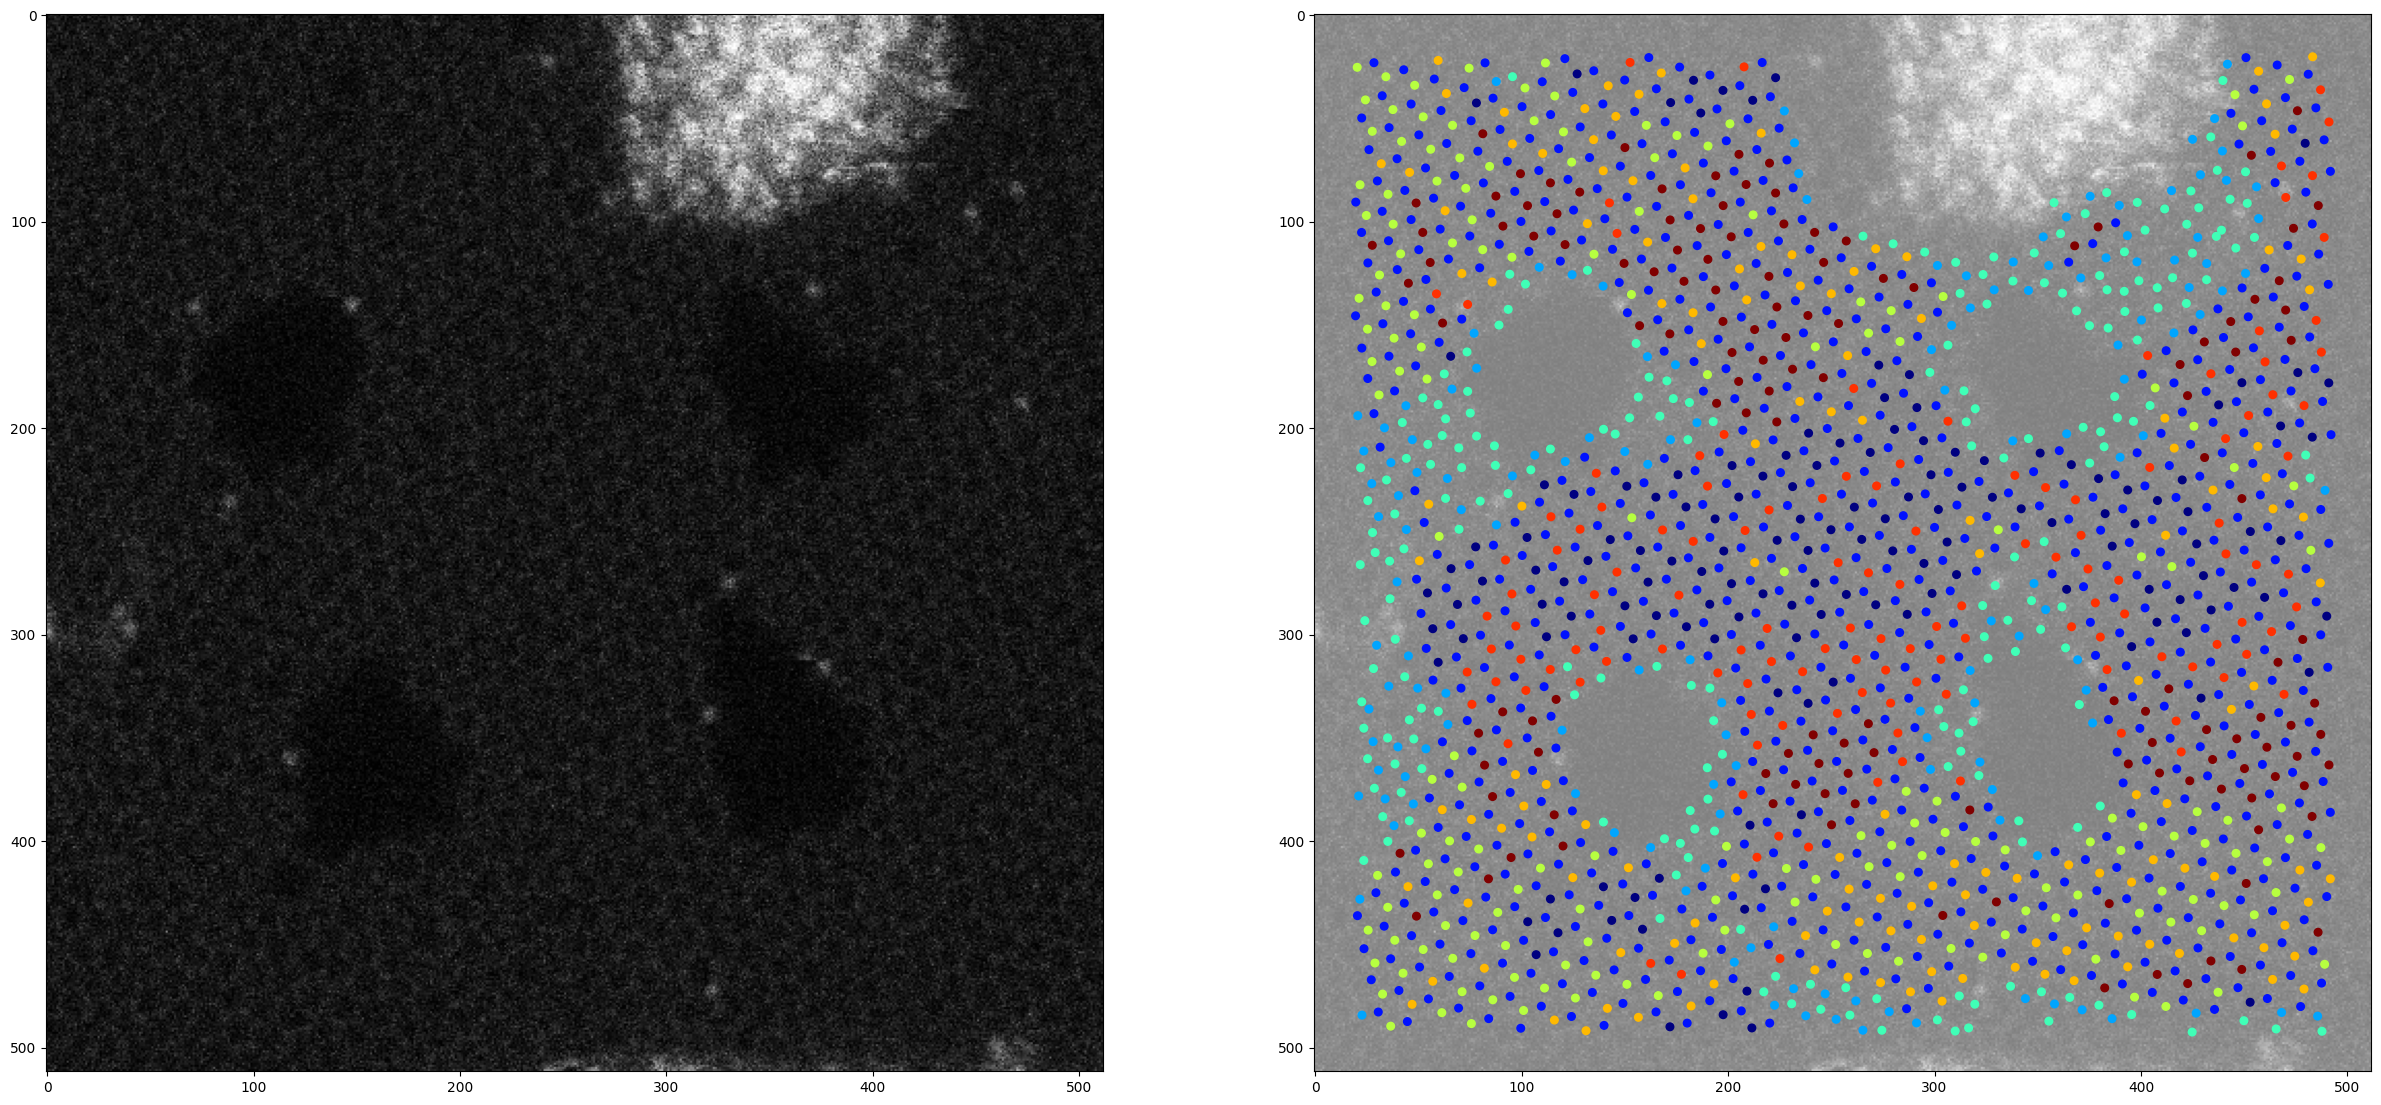

In [ ]:
#Visualizing the cluster labels on the raw STEM image

fig, ax = plt.subplots(1, 2, figsize=(30, 15))

ax[0].imshow(STEM_real[i,...,0], cmap="gray")
ax[1].imshow(STEM_real[i,...,0], cmap="gray", alpha = 0.5)
ax[1].scatter(com_all1[:, 1], com_all1[:, 0], c=gr_labels, s=30, cmap="jet")

plt.show()

# General comment for homework

Below I provide a set of analyses for Homework 4 using the data above. However, please feel free:
- run this analysis on the EELS data set available in the Notebook 8_Clustering_EELS on https://github.com/SergeiVKalinin/MSE_Fall2023/blob/main/Module%203/8_Clustering_EELS.ipynb
- Or your own dataset as may be relevant to your research. The data set should allow for meaningful classification and clustering
- You can also use different data sets for the two
- use the !gdown method to import the dataset into colab from link (do not use the mounting GDrive option - since I will not be able to access it)

# Homework Part I

1. Calculate the elbow curve for the k-means analysis above

2. Calculate the silhoutte for the k-means (or GMM - up to you)  for different number of clusters. Determine that optimal number of clusters for this data set and method.

3. Repeat this analysis for several wondow sizes (10, 20, 40, 60, 80). What is the optimal number of clusters for each of these window size? Rationalize these observations

Answer 3:

4. In class, we have explored the density based clustering tehcniques. Following the GMM and k-means clustering analysis above, run the same analysis using the density based clustering.

5. When exploring the analysis for window_size = 40, you will note that symmetry non-equivalent carbon atoms in sp2 configuration are classified into different groups. However, chemically these are equivalent. Suggest potential approach to avoid this problem.

6 (Optional - if well familiar with Python and want a challenge). Realize this approach

7. (Optional - if well familiar with Python and want a challenge). Analyze the stack of images using k-means clustering and plot the evolution of cluster fractions as a function of time.

# Homework Part II

After running the analysis in the previous sections, we now have access to the k-means clustering results of the image patches. Effectively, each atom in the image is now associated with the patch centered on this atom, and the cluster label. The y_km is a label array, and km.cluster_centers_ is the centroid of the clustes. Remember that you need to reshape it back to (window_size, window_size) in order to get the image. We also have access to the imstack2 object, which is a collection of all patches, and com_all1 object that contains the information on the coordinate from which the patch has come from.

In [ ]:
y_km.shape, km.cluster_centers_.shape, imstack2.shape, com_all1.shape

((1798,), (3, 1600), torch.Size([1798, 1600]), (1798, 2))

8. Create a X,y data set for a classification problem. Here, the image is a feature, and the cluster label is assumed to be known ground truth label (alternatively, we can do manual labelling, but for the purpose of excercise let's assume that ground truth labels are already known).

9. Use the train_test_split function to create the training set and test set for classification problem.

10. Run the logistics classification on the data and plot the confucion matrix and ROC curve

11. Run the CART classification on the data and plot the decision tree and ROC curve. Is this analysis meaningful?

Answer 11:

12. Run the XGBoost classification on the dataset and plot the ROC curve.